In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

In [4]:
data = load_iris()

In [5]:
data

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [8]:
df = pd.DataFrame(data.data,columns=data.feature_names)
df["target"] = data.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [9]:
df.shape

(150, 5)

In [10]:
df.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
dtype: object

In [11]:
df["target"].unique()

array([0, 1, 2])

In [12]:
df["target"].value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

In [13]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

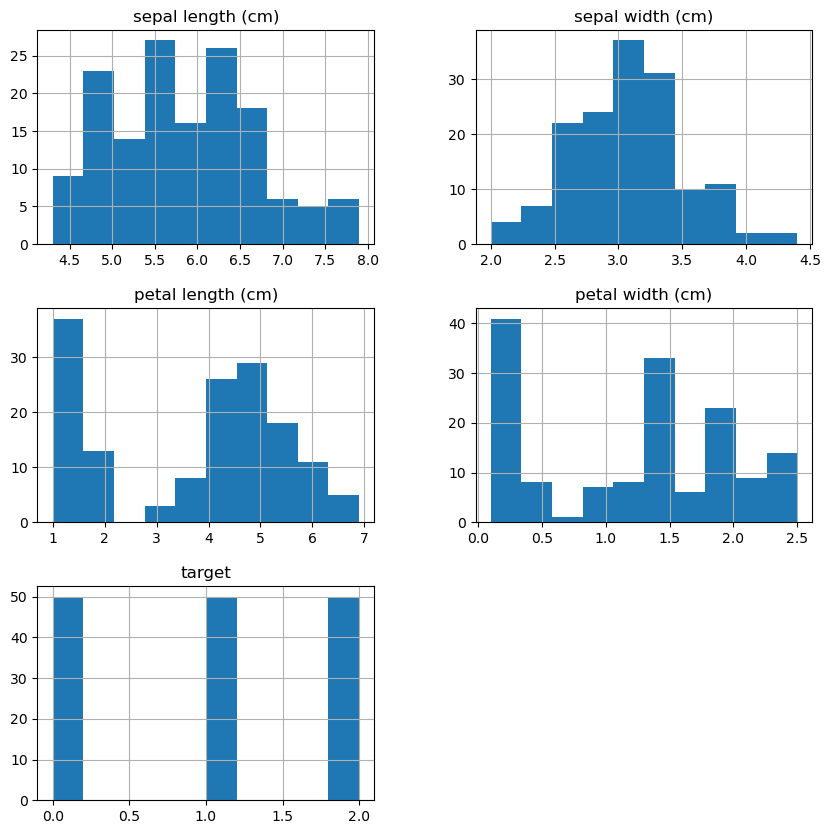

In [16]:
df.hist(figsize=(10,10))
plt.show()

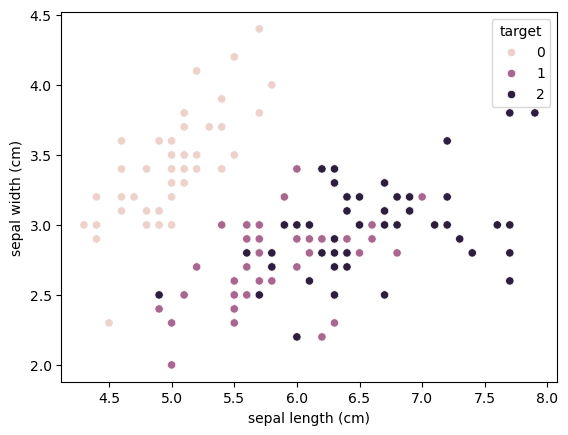

In [18]:
sns.scatterplot(x="sepal length (cm)",y="sepal width (cm)",data=df,hue="target")
plt.show()

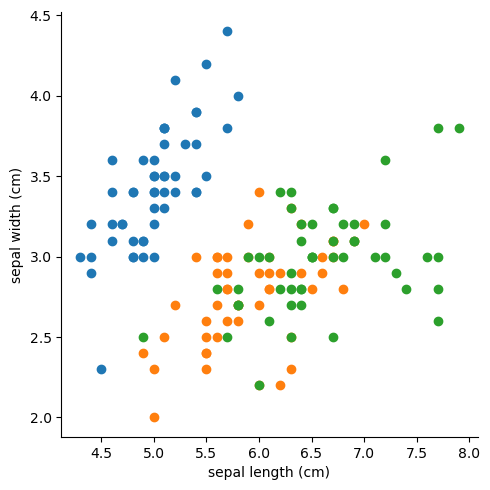

In [20]:
sns.FacetGrid(df,hue="target",height=5).map(plt.scatter,"sepal length (cm)","sepal width (cm)")
plt.show()

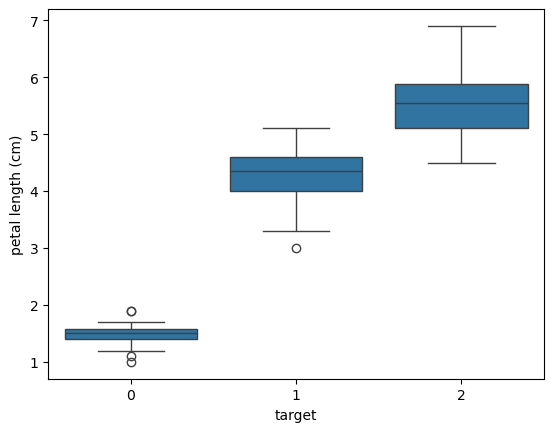

In [23]:
sns.boxplot(x="target",y="petal length (cm)",data=df)
plt.show()

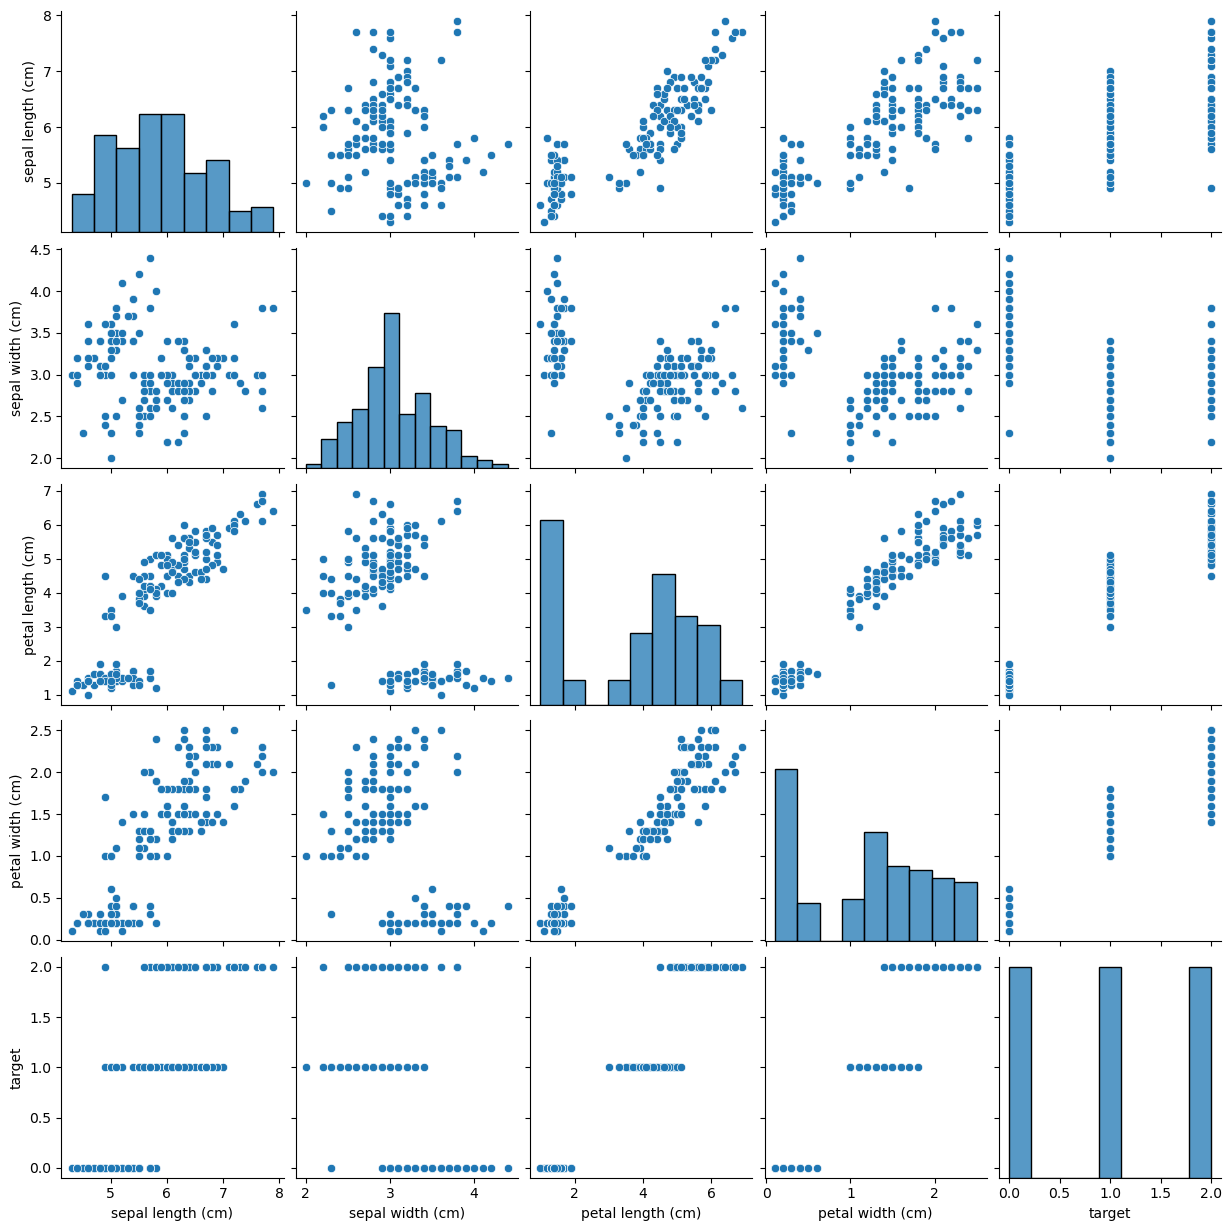

In [24]:
sns.pairplot(data=df)
plt.show()

In [25]:
df.corr()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
sepal length (cm),1.000000,-0.117570,0.871754,0.817941,0.782561
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126,-0.426658
petal length (cm),0.871754,-0.428440,1.000000,0.962865,0.949035
petal width (cm),0.817941,-0.366126,0.962865,1.000000,0.956547
target,0.782561,-0.426658,0.949035,0.956547,1.000000


In [26]:
X = df.drop("target",axis=1)
y = df["target"]

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=1)

In [28]:
model = SVC(C=1)

In [29]:
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

In [30]:
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

[[14  0  0]
 [ 0 17  1]
 [ 0  0 13]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      0.94      0.97        18
           2       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45

0.9777777777777777


In [31]:
from sklearn.model_selection import cross_val_score

In [32]:
scores = cross_val_score(model,X_train,y_train,cv=5)
scores

array([1.        , 0.95238095, 1.        , 0.9047619 , 0.95238095])

In [33]:
from sklearn.model_selection import GridSearchCV

In [34]:
param_grid = {
    "C" : [0.1,1,10,100,1000]
}
grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5
)

In [35]:
grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=SVC(), param_grid={'C': [0.1, 1, 10, 100, 1000]})

In [37]:
griddf = pd.DataFrame(grid.cv_results_)
griddf.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.004370,0.000711,0.002671,0.000152,0.1,{'C': 0.1},0.714286,0.857143,0.857143,0.809524,0.714286,0.790476,0.064594,5
1,0.004616,0.000735,0.003466,0.000840,1.0,{'C': 1},1.000000,0.952381,1.000000,0.904762,0.952381,0.961905,0.035635,2
2,0.002402,0.000235,0.001473,0.000146,10.0,{'C': 10},1.000000,0.952381,1.000000,0.952381,0.952381,0.971429,0.023328,1
3,0.001524,0.000165,0.001085,0.000089,100.0,{'C': 100},1.000000,0.904762,1.000000,0.904762,0.809524,0.923810,0.071270,4
4,0.001386,0.000023,0.001021,0.000071,1000.0,{'C': 1000},1.000000,0.952381,0.952381,0.904762,0.857143,0.933333,0.048562,3


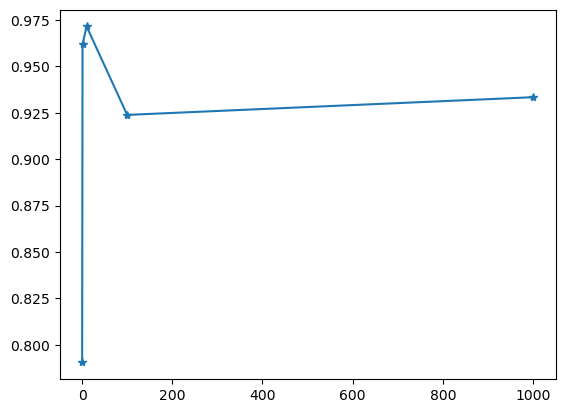

In [40]:
plt.plot(param_grid["C"],griddf["mean_test_score"],marker="*")
plt.show()

In [41]:
grid.best_score_

np.float64(0.9714285714285715)

In [43]:
grid.best_params_

{'C': 10}

## LAB 10

In [44]:
df = pd.read_csv("/home/badam/Documents/ML/ML_LAB/Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [45]:
X = df[["Annual Income (k$)","Spending Score (1-100)"]]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [47]:
from sklearn.cluster import KMeans

In [48]:
wcss = []

In [49]:
for k in range(5):
    model = KMeans(n_clusters=k+1)
    model.fit(X)
    wcss.append(model.inertia_)
wcss

[269981.28,
 184609.98434090626,
 106348.37306211122,
 73679.78903948836,
 66674.36000494967]

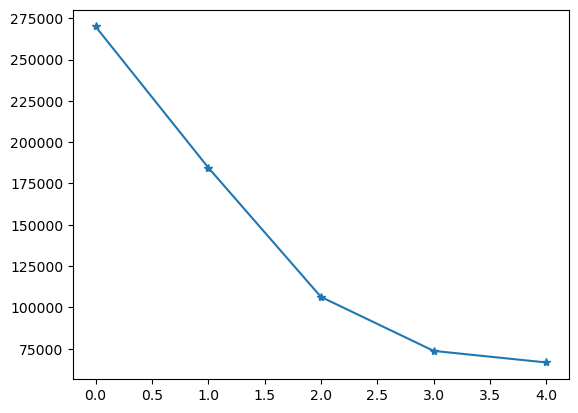

In [51]:
plt.plot(range(5),wcss,marker="*")
plt.show()

In [58]:
model = KMeans(n_clusters=5)

In [59]:
model.fit(X)

KMeans(n_clusters=5)

In [60]:
y_pred = model.predict(X)
y_pred

array([3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4,
       3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 0,
       3, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 2, 0, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 0, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2], dtype=int32)

In [64]:
labels = model.labels_
centroids = model.cluster_centers_

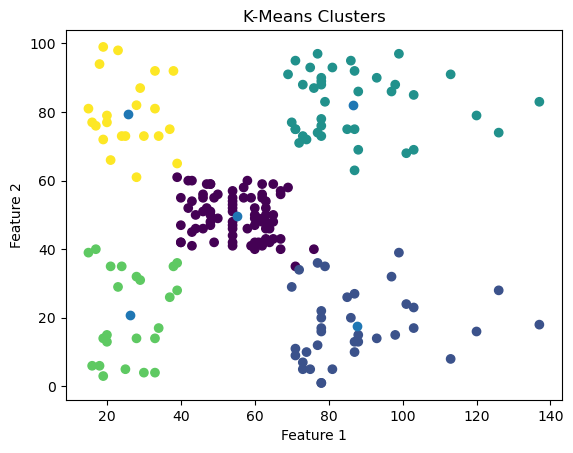

In [71]:
labels = model.labels_
centroids = model.cluster_centers_

plt.scatter(X["Annual Income (k$)"], X["Spending Score (1-100)"],c=labels)
plt.scatter(centroids[:,0],centroids[:,1])
plt.title("K-Means Clusters")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()